# Figuras curadas para la tesis

Único notebook de figuras: toma los datos crudos de los experimentos y produce
los archivos que se insertan en LaTeX. **No es un notebook de exploración** —
para eso están `F1_analisis.ipynb`, `F2_analisis.ipynb` y
`Fase_3_array_analysis.ipynb`. Acá cada figura es una decisión ya tomada.

**Criterios de diseño, comunes a todas las figuras:**

- **Tamaño.** Se generan al ancho exacto de la caja de texto de la tesis
  (`\textwidth` = 441,02 pt = 15,5 cm) y se insertan con
  `[width=\textwidth]`, de modo que el factor de escala sea 1,0 y los cuerpos
  tipográficos salgan del tamaño pedido (9 pt en ejes, 8 pt en marcas y
  leyenda) en lugar de estirarse o encogerse al importarlas.
- **Tipografía.** Sans humanista moderna (Inter), elegida sobre una serif tipo
  Times porque las etiquetas de esta sección son casi todas siglas en
  mayúsculas —`NM-MVDR`, `MPDR`, `PESQ`, `STOI`— y en una serif salen
  desproporcionadas respecto del resto.
- **Paleta Okabe-Ito**, segura para daltonismo. El color de cada serie se
  define **una sola vez** en `STYLE`: si una serie aparece en dos figuras,
  aparece con el mismo color y el mismo trazo.
- **Salida.** PDF vectorial (el que va en LaTeX) más PNG a 300 dpi para
  presentaciones, escritos directamente en el repositorio de la tesis.
- **Agregación por mediana** con banda intercuartílica, según el criterio del
  banco: SIR y SAR tienen colas largas que arrastran cualquier promedio.

**Orden de ejecución:** Configuración → Carga de datos → figuras.

## Configuración compartida

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# --- Rutas -------------------------------------------------------------------
# Los datos viven junto a este notebook; las figuras se escriben DIRECTO en el
# repositorio de la tesis, para no tener que copiarlas a mano.
DATA_DIR = Path("../data/Fase_1").resolve()
FIG_DIR = Path("/home/matias/Documents/Tesis/tesis_latex/Figuras/Modelado").resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Geometría de la página --------------------------------------------------
# \textwidth del documento, en pulgadas (441,02 pt de TeX / 72,27). Las figuras
# se generan a ESTE ancho y se insertan con [width=\textwidth]: escala 1,0.
TEXTWIDTH_IN = 441.02 / 72.27

# --- Paleta Okabe-Ito --------------------------------------------------------
OKABE_ITO = {
    "negro":     "#000000",
    "naranja":   "#E69F00",
    "celeste":   "#56B4E9",
    "verde":     "#009E73",
    "amarillo":  "#F0E442",
    "azul":      "#0072B2",
    "bermellon": "#D55E00",
    "purpura":   "#CC79A7",
}

# Gris oscuro de los contornos (cajas, bigotes, medianas). No es negro puro:
# a 0,9 pt el negro pleno se ve duro contra los rellenos claros.
TRAZO = "#333333"


def tint(color, blanco=0.55):
    """Mezcla un color con blanco, devolviendo un tono pastel del mismo matiz.

    Se usa para el RELLENO de las cajas: contorno oscuro sobre relleno claro.
    Rellenar con el color pleno y dibujar la mediana en blanco hace que el
    boxplot se lea 'en negativo'.
    """
    return tuple(c + (1.0 - c) * blanco for c in mpl.colors.to_rgb(color))


# --- Estilo por serie --------------------------------------------------------
# FUENTE ÚNICA DE VERDAD del color y el trazo de cada serie en toda la tesis.
# Agregar una serie nueva acá, no dentro de una figura.
#   Entrada / DTLN-mono son REFERENCIAS (no filtran espacialmente) -> trazo
#   discontinuo, para que se distingan de los procesadores de un vistazo.
STYLE = {
    "Entrada":   dict(color=OKABE_ITO["negro"],     ls=":",  marker="o"),
    "DTLN-mono": dict(color=OKABE_ITO["purpura"],   ls="-.", marker="v"),
    "DS":        dict(color=OKABE_ITO["verde"],     ls="-",  marker="^"),
    "MVDR-geo":  dict(color=OKABE_ITO["bermellon"], ls="-",  marker="s"),
    "MPDR":      dict(color=OKABE_ITO["azul"],      ls="-",  marker="D"),
    "NM-MVDR":   dict(color=OKABE_ITO["naranja"],   ls="-",  marker="o"),
}
# Reservado para cuando entren en escena (P3 / Fase 2), para no reasignar
# colores ya usados: celeste y amarillo siguen libres.

# --- Series de la Fase 1 -----------------------------------------------------
# (nombre, prefijo de columna, procesador a filtrar)
#   'base'       -> señal del micrófono de referencia, sin procesar
#   'dtln_alone' -> DTLN monoaural sobre ese mismo canal
#   'proc'       -> salida del procesador indicado
# Entrada y DTLN-mono NO dependen del procesador: se leen del cuadro de escenas
# únicas, porque cada escena aparece repetida una vez por beamformer corrido.
# El ORDEN de esta lista es el orden de las cajas y de la leyenda.
SERIES = [
    ("Entrada",   "base",       None),
    ("MVDR-geo",  "proc",       "MVDR-geo"),
    ("MPDR",      "proc",       "MPDR"),
    ("DTLN-mono", "dtln_alone", None),
    ("NM-MVDR",   "proc",       "NM-MVDR"),
]
ORDER = [s[0] for s in SERIES]

# Claves que identifican una escena física (sin el procesador).
SCENE_KEYS = ["source", "rt60", "isir_db", "target_angle", "target_dist",
              "N_interferences"]

METRIC_LABEL = {
    "PESQ": "PESQ", "STOI": "STOI", "SI-SDR": "SI-SDR [dB]",
    "SDR": "SDR [dB]", "SIR": "SIR [dB]", "SAR": "SAR [dB]",
}

# --- Rango vertical de las métricas acotadas ---------------------------------
# Se aplica SOLO a la figura de resultados generales, que es la que fija la
# lectura absoluta de la sección; las figuras de tendencia comparan curvas entre
# sí y ahí el rango lo fijan los datos.
#   STOI -> escala completa [0, 1]. Es acotada, los datos ocupan de 0,38 a 0,97
#           y mostrarla entera se paga con muy poca resolución.
#   PESQ -> se ancla el PISO en 1,0, que es el mínimo real de la métrica y donde
#           efectivamente está la señal de entrada. El techo NO se lleva a 4,5:
#           ese valor corresponde a habla prácticamente limpia, inalcanzable en
#           este escenario, y dejarlo dentro comprimiría toda la comparación en
#           el tercio inferior del eje. Para forzar la escala completa:
#           METRIC_LIMS["PESQ"] = (1.0, 4.5).
#   SI-SDR / SIR -> no son acotadas; no llevan entrada acá.
METRIC_LIMS = {"PESQ": (1.0, None), "STOI": (0.0, 1.0)}

# --- Estilo de matplotlib ----------------------------------------------------
# Sans humanista moderna. Inter tiene mayúsculas de proporción contenida, que es
# lo que necesitan los nombres de los algoritmos (NM-MVDR, MPDR) y las métricas
# (PESQ, STOI): en una serif tipo Times esas siglas salen desproporcionadas.
_SANS = ["Inter", "Lato", "Roboto", "Open Sans", "Liberation Sans", "DejaVu Sans"]
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": _SANS,
    # mathtext en la MISMA familia, para que $RT_{60}$ no cambie de tipografía
    # respecto del resto de la etiqueta.
    "mathtext.fontset": "custom",
    "mathtext.rm": _SANS[0],
    "mathtext.it": f"{_SANS[0]}:italic",
    "mathtext.bf": f"{_SANS[0]}:bold",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.edgecolor": TRAZO,
    "axes.labelcolor": TRAZO,
    "text.color": TRAZO,
    "xtick.color": TRAZO,
    "ytick.color": TRAZO,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.35,
    "lines.linewidth": 1.1,
    "lines.markersize": 3.3,
    "figure.dpi": 120,
    # bbox 'standard' (NO 'tight'): recortar el borde cambiaría el ancho del PDF
    # y LaTeX lo re-escalaría, alterando el tamaño real de la tipografía.
    "savefig.bbox": "standard",
    "pdf.fonttype": 42,   # TrueType embebido; evita Type 3
    "ps.fonttype": 42,
})


def save_fig(fig, name, png=True):
    """Escribe la figura en el repositorio de la tesis: PDF (LaTeX) y PNG (slides)."""
    salidas = [FIG_DIR / f"{name}.pdf"]
    fig.savefig(salidas[0])
    if png:
        salidas.append(FIG_DIR / f"{name}.png")
        fig.savefig(salidas[1], dpi=300)
    w, h = fig.get_size_inches()
    print(f"[ok] {name}  {w * 2.54:.1f} x {h * 2.54:.1f} cm  ->  "
          f"{', '.join(p.name for p in salidas)}")
    return salidas


def col(prefix, metric):
    """Nombre de columna de una métrica. Toda la Fase 1 se mide contra la
    referencia temprana, de ahí el sufijo `_early`."""
    return f"{prefix}_{metric}_early"


def filas(df, escenas, proc):
    """Filas sobre las que se lee una serie: el cuadro de escenas únicas si la
    serie no depende del procesador, o las filas de ese procesador si depende."""
    return escenas if proc is None else df[df["processor"] == proc]

## Carga de datos

In [2]:
def load_exp(name):
    """Carga un experimento de la Fase 1.

    Los `inf` de SIR/SAR se convierten a NaN una sola vez, acá: son valores
    reales (escenas donde la interferencia residual se anula exactamente) pero
    rompen cualquier agregado, así que se los descarta en el origen.
    """
    d = DATA_DIR / name
    parquet = d / "mird_benchmark_metrics.parquet"
    df = pd.read_parquet(parquet) if parquet.exists() \
        else pd.read_csv(d / "mird_benchmark_metrics.csv")
    return df.replace([np.inf, -np.inf], np.nan)


df_P1 = load_exp("P1_diversidad")
df_doa = load_exp("P2_doa")
df_gain = load_exp("P2_gain")
df_phase = load_exp("P2_phase")

# Una fila por escena física: las de P1 vienen repetidas una vez por procesador.
escenas_P1 = df_P1.drop_duplicates(subset=SCENE_KEYS)

print(f"P1   {len(df_P1):5d} filas | {len(escenas_P1)} escenas | "
      f"procesadores: {', '.join(sorted(df_P1.processor.unique()))}")
for nombre, d in [("doa", df_doa), ("gain", df_gain), ("phase", df_phase)]:
    print(f"P2-{nombre:<5s} {len(d):5d} filas")

faltan = [p for _, pref, p in SERIES if p and p not in set(df_P1.processor)]
assert not faltan, f"Faltan procesadores en P1: {faltan}"

P1    1728 filas | 432 escenas | procesadores: DS, MPDR, MVDR-geo, NM-MVDR
P2-doa      40 filas
P2-gain     32 filas
P2-phase    32 filas


## Figura 1 — Distribución sobre el envolvente de diversidad acústica (P1)

Distribución de cada métrica en valores absolutos sobre las 432 escenas de P1
(2 locutores × 3 $RT_{60}$ × 3 ángulos × 2 distancias × 3 cantidades de
interferentes × 4 iSIR), una caja por serie.

Las series van ordenadas de menor a mayor desempeño esperado, con la Entrada a
la izquierda como punto de partida y el NM-MVDR a la derecha. La línea punteada
es la mediana de la Entrada: **la distancia de cada caja a esa línea es la
mejora**, que es lo que permite mostrar valores absolutos sin perder la lectura
de cuánto aporta cada procesador.

**Escala vertical.** Esta es la figura que fija la lectura absoluta de la
sección, así que las métricas acotadas se muestran contra su escala real y no
contra el rango de los datos: STOI va completa, de 0 a 1, y PESQ arranca en 1,0,
que es su mínimo posible y donde efectivamente está la señal de entrada. El
techo de PESQ (4,5) queda fuera a propósito: corresponde a habla prácticamente
limpia, inalcanzable en estas condiciones, y meterlo en el eje comprimiría toda
la comparación en el tercio inferior. Se cambia en `METRIC_LIMS`.

`DS` queda fuera de la figura por decisión de curaduría: es el conformador
geométrico no adaptativo y su comportamiento no aporta al argumento de la
selección. Sigue estando en los datos y en el notebook de análisis.

[ok] F1_P1_boxplot  15.5 x 11.9 cm  ->  F1_P1_boxplot.pdf, F1_P1_boxplot.png


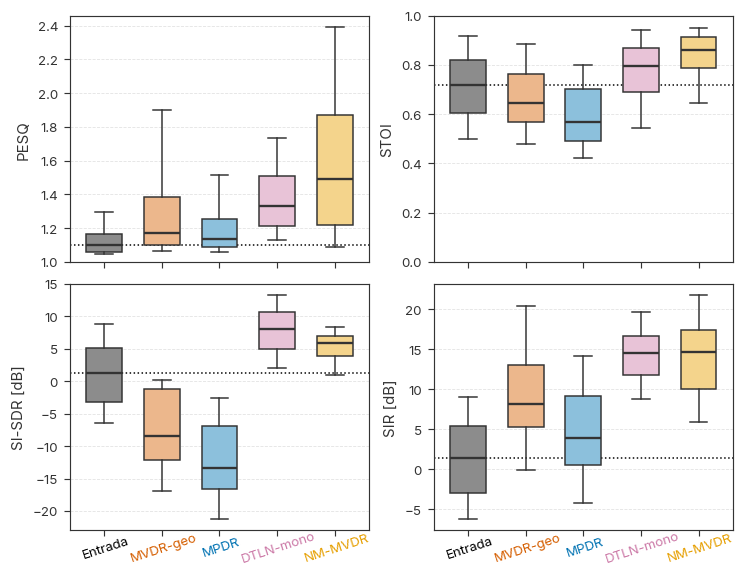

In [3]:
METRICS_BOX = ["PESQ", "STOI", "SI-SDR", "SIR"]

fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 4.7), layout="constrained")

for ax, metric in zip(axes.ravel(), METRICS_BOX):
    datos, colores = [], []
    for nombre, prefijo, proc in SERIES:
        src = filas(df_P1, escenas_P1, proc)
        datos.append(src[col(prefijo, metric)].dropna().values)
        colores.append(STYLE[nombre]["color"])

    # Contorno oscuro sobre relleno pastel: es lo que hace legible la caja.
    # Bigotes a P5-P95 y SIN atípicos individuales: con miles de escenas por
    # serie, los círculos de atípicos por default (>1.5 IQR) se acumulan en
    # una nube que ensucia la figura sin agregar información nueva.
    bp = ax.boxplot(
        datos, positions=np.arange(len(datos)), widths=0.62, patch_artist=True,
        whis=(5, 95), showfliers=False,
        boxprops=dict(lw=0.9, edgecolor=TRAZO),
        medianprops=dict(color=TRAZO, lw=1.4),
        whiskerprops=dict(color=TRAZO, lw=0.9),
        capprops=dict(color=TRAZO, lw=0.9),
    )
    for caja, c in zip(bp["boxes"], colores):
        caja.set_facecolor(tint(c))

    # Mediana de la Entrada: referencia visual de cuánta mejora aporta cada caja.
    ax.axhline(np.nanmedian(datos[0]), color=STYLE["Entrada"]["color"],
               ls=":", lw=0.9, zorder=0)

    # Métricas acotadas: se muestra la escala completa (STOI) o al menos el piso
    # real de la métrica (PESQ). Ver METRIC_LIMS en la celda de configuración.
    lo, hi = METRIC_LIMS.get(metric, (None, None))
    ax.set_ylim(bottom=lo, top=hi)

    ax.set_ylabel(METRIC_LABEL[metric])
    ax.set_xlim(-0.6, len(datos) - 0.4)
    ax.set_xticks(np.arange(len(ORDER)))
    ax.grid(axis="y")
    ax.set_axisbelow(True)

# Etiquetas de categoría solo en la fila inferior: las dos filas comparten el
# mismo eje x y repetirlas gasta altura sin agregar información. Coloreadas
# por serie (mismo criterio que las Figuras 5 y 10 de la Fase 3).
for ax in axes[0]:
    ax.set_xticklabels([])
for ax in axes[1]:
    ax.set_xticklabels(ORDER, rotation=18, ha="center", rotation_mode="anchor")
    for lbl, nombre in zip(ax.get_xticklabels(), ORDER):
        lbl.set_color(STYLE[nombre]["color"])

save_fig(fig, "F1_P1_boxplot")
plt.show()

## Figura 2 — Tendencias sobre los tres ejes de la grilla (P1)

Mediana de cada métrica contra los tres ejes principales del barrido, con la
banda intercuartílica (P25–P75) entre escenas detrás de cada curva de
procesador. Entrada y DTLN-mono van sin banda, para no saturar la figura.

Cada fila comparte escala vertical, de modo que las tres columnas de una métrica
sean comparables entre sí a simple vista.

> **Nota.** Pediste "3×3" pero también sólo PESQ y STOI, que dan dos filas; la
> figura quedó en **2 filas × 3 columnas**. Para agregar una tercera métrica
> alcanza con sumarla a `METRICS_TREND`: el resto se acomoda solo.

[ok] F1_P1_tendencias  15.5 x 9.4 cm  ->  F1_P1_tendencias.pdf, F1_P1_tendencias.png


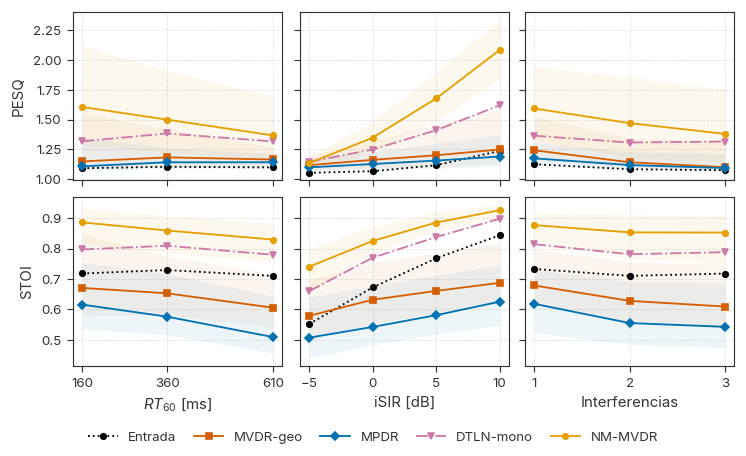

In [4]:
METRICS_TREND = ["PESQ", "STOI"]

# (columna del DataFrame, etiqueta del eje, escala, marcas del eje)
EJES_P1 = [
    ("rt60",            r"$RT_{60}$ [ms]", 1000.0, [160, 360, 610]),
    ("isir_db",         "iSIR [dB]",       1.0,    [-5, 0, 5, 10]),
    ("N_interferences", "Interferencias",  1.0,    [1, 2, 3]),
]

fig, axes = plt.subplots(len(METRICS_TREND), len(EJES_P1),
                         figsize=(TEXTWIDTH_IN, 3.7),
                         sharex="col", sharey="row", layout="constrained")

for r, metric in enumerate(METRICS_TREND):
    for c, (xcol, xlabel, xesc, xticks) in enumerate(EJES_P1):
        ax = axes[r, c]
        for nombre, prefijo, proc in SERIES:
            src = filas(df_P1, escenas_P1, proc)
            g = src.groupby(xcol)[col(prefijo, metric)]
            med = g.median().sort_index()
            x = med.index.values * xesc
            st = STYLE[nombre]
            if proc is not None:   # banda RIC solo para los procesadores
                p25 = g.quantile(0.25).reindex(med.index).values
                p75 = g.quantile(0.75).reindex(med.index).values
                ax.fill_between(x, p25, p75, color=tint(st["color"], 0.35), alpha=0.1, lw=0)
            ax.plot(x, med.values, color=st["color"], ls=st["ls"],
                    marker=st["marker"], label=nombre)

        ax.set_xticks(xticks)
        ax.grid(True)
        ax.set_axisbelow(True)
        if r == len(METRICS_TREND) - 1:
            ax.set_xlabel(xlabel)
        if c == 0:
            ax.set_ylabel(METRIC_LABEL[metric])

handles = [Line2D([0], [0], color=STYLE[n]["color"], ls=STYLE[n]["ls"],
                  marker=STYLE[n]["marker"], label=n) for n in ORDER]
fig.legend(handles=handles, loc="outside lower center", ncol=len(ORDER),
           frameon=False, handlelength=2.2, columnspacing=1.3)

save_fig(fig, "F1_P1_tendencias")
plt.show()

## Figura 3 — Robustez ante error de apuntamiento y desajuste del sensor (P2)

Tres barridos unidimensionales independientes sobre una escena acústica **fija**
($RT_{60}$ = 360 ms, objetivo en broadside a 1 m, iSIR = 0 dB, 3 interferentes),
en la que se varía por separado el error de DOA, el desajuste de ganancia y el
de fase entre micrófonos.

El error de DOA es el barrido decisivo: sólo afecta a los procesadores que
asumen una posición nominal de la fuente (`MVDR-geo` y `MPDR`), mientras que el
`NM-MVDR` no la usa y debe quedar plano.

Acá **no** se dibuja la banda intercuartílica: cada punto agrega únicamente los
dos locutores, y un rango intercuartílico sobre dos muestras no informa
dispersión, sólo interpola entre ambas. Entrada y DTLN-mono se calculan contra
el eje del barrido en lugar de trazarse como líneas horizontales, porque los
desajustes de ganancia y fase alteran también la señal del micrófono de
referencia; que salgan casi planas es un resultado, no un supuesto.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


[ok] F1_P2_robustez  15.5 x 9.4 cm  ->  F1_P2_robustez.pdf, F1_P2_robustez.png


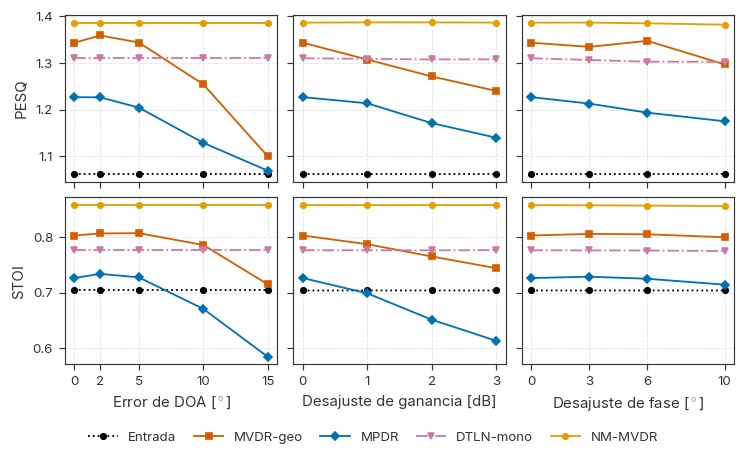

In [5]:
# (DataFrame, columna del eje, etiqueta)
EJES_P2 = [
    (df_doa,   "error_angle_deg", "Error de DOA [$^\\circ$]"),
    (df_gain,  "mismatch_gain",   "Desajuste de ganancia [dB]"),
    (df_phase, "mismatch_phase",  "Desajuste de fase [$^\\circ$]"),
]

fig, axes = plt.subplots(len(METRICS_TREND), len(EJES_P2),
                         figsize=(TEXTWIDTH_IN, 3.7),
                         sharex="col", sharey="row", layout="constrained")

for r, metric in enumerate(METRICS_TREND):
    for c, (df_e, xcol, xlabel) in enumerate(EJES_P2):
        ax = axes[r, c]
        # El eje del barrido forma parte de la identidad de la escena acá.
        escenas_e = df_e.drop_duplicates(subset=SCENE_KEYS + [xcol])
        for nombre, prefijo, proc in SERIES:
            src = filas(df_e, escenas_e, proc)
            med = src.groupby(xcol)[col(prefijo, metric)].median().sort_index()
            st = STYLE[nombre]
            ax.plot(med.index.values, med.values, color=st["color"],
                    ls=st["ls"], marker=st["marker"], label=nombre)

        ax.set_xticks(sorted(df_e[xcol].unique()))
        ax.grid(True)
        ax.set_axisbelow(True)
        if r == len(METRICS_TREND) - 1:
            ax.set_xlabel(xlabel)
        if c == 0:
            ax.set_ylabel(METRIC_LABEL[metric])

fig.legend(handles=handles, loc="outside lower center", ncol=len(ORDER),
           frameon=False, handlelength=2.2, columnspacing=1.3)

save_fig(fig, "F1_P2_robustez")
plt.show()

## Fase 2 — Selección del post-filtro

Sobre el NM-MVDR ya seleccionado en la Fase 1 se evalúan las variantes de
post-procesamiento: `BAN` (normalización analítica ciega), `PF` (post-filtro de
sustracción espectral, parametrizado por el factor de suavizado `smooth`) y
`BANPF` (BAN seguida de PF), cada una con `smooth` ∈ {0,2; 0,5; 0,8} donde
aplica — 8 variantes en total. El banco calcula además, para cada una de esas 8
variantes, la cascada con el DTLN completo aplicado a su salida (`+DTLN-post`,
el segundo núcleo de la red operando como post-filtro), lo que da 16 cadenas.

Datos: barrido $RT_{60}$ × iSIR × layout de interferentes × locutor, 48 escenas.

In [6]:
import re

DATA_DIR_F2 = Path("../data/Fase_2").resolve()
df_F2 = pd.read_parquet(DATA_DIR_F2 / "mird_benchmark_metrics.parquet")
df_F2 = df_F2.replace([np.inf, -np.inf], np.nan)

# Nombres de processor: NM-MVDR_L1e-06 | BAN_L1e-06 | PF_0.5_L1e-06 | BANPF_0.8_L1e-06
_PROC_RE = re.compile(r"(NM-MVDR|BANPF|BAN|PF)(?:_([0-9.]+))?_L(\S+)$")


def parse_processor(name):
    m = _PROC_RE.match(name)
    fam, s, _L = m.group(1), m.group(2), m.group(3)
    return pd.Series({"family": fam, "smooth": float(s) if s is not None else np.nan})


df_F2 = df_F2.join(df_F2["processor"].apply(parse_processor))

# Colores de familia. NM-MVDR conserva el naranja que ya tiene en la Fase 1
# (mismo procesador, misma identidad visual en todo el documento). BAN/PF/BANPF
# son nuevas EN ESTA FASE y no comparten ninguna figura con MVDR-geo/MPDR (ya
# descartados en la Fase 1) -> se reciclan celeste/amarillo/bermellón sin salir
# de la paleta Okabe-Ito de 8 colores. El amarillo se dibuja siempre con borde
# TRAZO: por diseño de la paleta es el de menor contraste sobre blanco.
FAMILY_COLOR = {
    "NM-MVDR": STYLE["NM-MVDR"]["color"],
    "BAN": OKABE_ITO["celeste"],
    "PF": OKABE_ITO["amarillo"],
    "BANPF": OKABE_ITO["bermellon"],
}
POST_MARKER = {False: "o", True: "D"}   # sin DTLN-post / + DTLN-post
FAMILY_ORDER_F2 = ["NM-MVDR", "BAN", "PF", "BANPF"]

# Orden de las 8 variantes: por familia y, dentro de cada una, por smooth.
procesadores_F2 = []
for fam in FAMILY_ORDER_F2:
    procesadores_F2 += sorted(df_F2.loc[df_F2.family == fam, "processor"].unique(),
                              key=lambda p: parse_processor(p)["smooth"] if not
                              np.isnan(parse_processor(p)["smooth"]) else -1)

# Escenas únicas de esta corrida (Entrada/DTLN-mono no dependen del procesador).
SCENE_KEYS_F2 = ["source", "rt60", "isir_db", "N_interferences", "target_angle", "target_dist"]
escenas_F2 = df_F2.drop_duplicates(subset=SCENE_KEYS_F2)

print(f"Fase 2: {len(df_F2)} filas | {len(escenas_F2)} escenas | {len(procesadores_F2)} variantes")
print("variantes:", procesadores_F2)

Fase 2: 384 filas | 48 escenas | 8 variantes
variantes: ['NM-MVDR_L1e-06', 'BAN_L1e-06', 'PF_0.2_L1e-06', 'PF_0.5_L1e-06', 'PF_0.8_L1e-06', 'BANPF_0.2_L1e-06', 'BANPF_0.5_L1e-06', 'BANPF_0.8_L1e-06']


### Tabla resumen (filas listas para pegar en LaTeX)

Mediana de cada métrica por variante, **sin** la rama `+DTLN-post`: esa
dimensión queda para la figura de trade-off, que la muestra con el conector
circulo→diamante. La tabla es, a propósito, el resumen completo por métrica
(las cinco a la vez); la figura es el resumen completo por post-filtro (con y
sin DTLN-post). Se marca en negrita (`\best`) la mejor variante de cada columna,
entre las 8 candidatas (Entrada/DTLN-mono son referencia, no compiten).

In [7]:
METRICS_F2 = ["PESQ", "STOI", "SI-SDR", "SIR", "SAR"]
# Decimales por métrica: PESQ/STOI acotadas y con diferencias finas -> 3
# decimales; las métricas en dB, con rangos de varios dB entre variantes -> 1.
NDEC_F2 = {"PESQ": 3, "STOI": 3, "SI-SDR": 1, "SIR": 1, "SAR": 1}


def fmt_f2(v, metric):
    """Numero con coma decimal (convencion del documento), sin usar locale."""
    return f"{v:.{NDEC_F2[metric]}f}".replace(".", ",")


def display_name_f2(processor):
    fam, s = parse_processor(processor)
    if fam == "NM-MVDR":
        return "NM-MVDR (base)"
    if fam == "BAN":
        return "BAN"
    return f"{fam} ($s=0{{,}}{int(round(s * 10))}$)"


tab_f2 = pd.DataFrame({
    p: {m: df_F2.loc[df_F2.processor == p, f"proc_{m}_early"].median() for m in METRICS_F2}
    for p in procesadores_F2
}).T.loc[procesadores_F2]
mejor_f2 = {m: tab_f2[m].idxmax() for m in METRICS_F2}   # las 5 metricas: mayor es mejor

ref_f2 = {
    "Entrada": {m: escenas_F2[f"base_{m}_early"].median() for m in METRICS_F2},
    "DTLN-mono": {m: escenas_F2[f"dtln_alone_{m}_early"].median() for m in METRICS_F2},
}

print(r"% --- filas de referencia ---")
for nombre, vals in ref_f2.items():
    celdas = " & ".join(fmt_f2(vals[m], m) for m in METRICS_F2)
    print(f"{nombre} & {celdas} \\\\")
print(r"\midrule")
print(r"% --- filas de variantes (negrita = mejor de la columna) ---")
for p in procesadores_F2:
    celdas = []
    for m in METRICS_F2:
        v = fmt_f2(tab_f2.loc[p, m], m)
        celdas.append(f"\\best{{{v}}}" if mejor_f2[m] == p else v)
    print(f"{display_name_f2(p)} & {' & '.join(celdas)} \\\\")

% --- filas de referencia ---
Entrada & 1,107 & 0,755 & 2,1 & 2,2 & 28,4 \\
DTLN-mono & 1,382 & 0,841 & 8,9 & 16,2 & 10,7 \\
\midrule
% --- filas de variantes (negrita = mejor de la columna) ---
NM-MVDR (base) & 1,797 & 0,913 & 7,4 & 17,1 & 10,7 \\
BAN & 1,499 & \best{0,914} & 7,6 & 12,9 & 10,6 \\
PF ($s=0{,}2$) & 1,977 & 0,888 & 5,3 & \best{19,0} & 9,8 \\
PF ($s=0{,}5$) & \best{2,019} & 0,904 & 6,3 & 18,0 & 10,2 \\
PF ($s=0{,}8$) & 1,878 & 0,911 & 7,0 & 17,6 & 10,5 \\
BANPF ($s=0{,}2$) & 1,712 & 0,892 & 7,4 & 16,7 & 10,6 \\
BANPF ($s=0{,}5$) & 1,627 & 0,908 & \best{8,0} & 15,0 & \best{11,1} \\
BANPF ($s=0{,}8$) & 1,533 & 0,914 & 7,8 & 13,3 & 11,0 \\


### Figura 4 — Trade-off PESQ vs STOI (16 cadenas)

Un punto por cadena (mediana sobre las 48 escenas), con barras de error finas
(RIC, P25–P75). El color identifica la familia; el marcador, si lleva el DTLN
completo en cascada sobre su salida (círculo = sin post, diamante = con
`+DTLN-post`); el número junto al punto es el `smooth` de PF/BANPF. El conector
gris une cada variante con su versión `+DTLN-post`, para leer de un vistazo en
qué dirección la mueve el segundo núcleo de la red.

A diferencia de la Figura 1, acá el rango de los ejes lo fijan los datos: esta
figura compara posiciones relativas entre 16 cadenas, no establece la lectura
absoluta de la sección (eso ya lo hizo la Figura 1 sobre la Fase 1).

`Entrada` queda fuera de esta figura por decisión de curaduría: ya se estableció en la Figura 1 que filtrar espacialmente vale la pena, así que acá el punto de comparación relevante es `DTLN-mono` (el techo sin arreglo), no la señal cruda — y sacarla deja más resolución vertical para las 16 cadenas, que es el argumento de esta figura.

[ok] F2_tradeoff  15.5 x 10.5 cm  ->  F2_tradeoff.pdf, F2_tradeoff.png


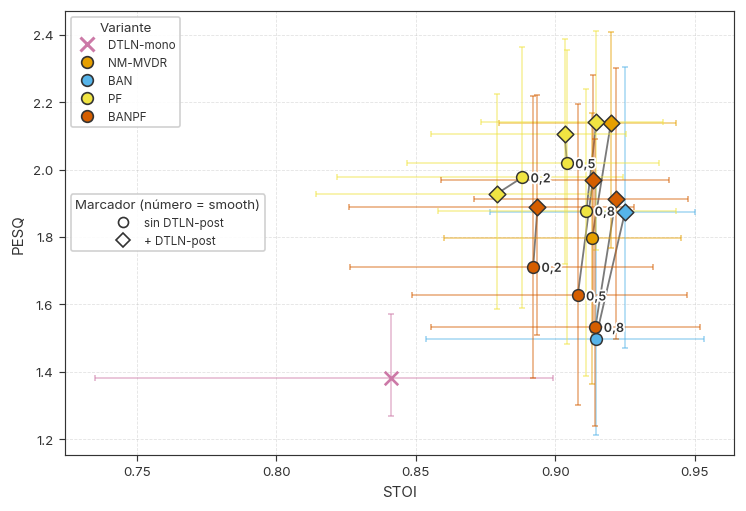

In [8]:
MSIZE_F2 = 50


def iqr_f2(v):
    """(mediana, error_inferior, error_superior) para error bars asimetricos."""
    v = v.dropna()
    med = v.median()
    return med, med - v.quantile(0.25), v.quantile(0.75) - med


def plot_pt_f2(ax, x, y, color, marker):
    mx, exlo, exhi = x
    my, eylo, eyhi = y
    ax.errorbar([mx], [my], xerr=[[exlo], [exhi]], yerr=[[eylo], [eyhi]],
                fmt="none", ecolor=color, elinewidth=0.9, capsize=1.6, alpha=0.55, zorder=2)
    if marker == "x":
        # 'x' es un marcador SIN relleno: matplotlib lo traza con 'color' y
        # descarta cualquier edgecolor (avisando por warning). El equivalente
        # a "engrosar el trazo" acá es linewidths, no edgecolor.
        ax.scatter([mx], [my], s=MSIZE_F2 * 1.3, marker=marker, color=color,
                  linewidths=1.6, zorder=3)
    else:
        ax.scatter([mx], [my], s=MSIZE_F2, marker=marker, color=color, edgecolor=TRAZO,
                  linewidth=0.9, zorder=3)
    return mx, my


import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.68), layout="constrained")

# DTLN-mono: el techo sin arreglo, sin distincion de post-filtro. Entrada
# queda fuera (ver nota de curaduria arriba): con ella adentro, el eje STOI
# tenia que arrancar en 0,64 para hacerle lugar y las 16 cadenas -que es el
# argumento real de esta figura- quedaban todas apretadas contra el borde
# derecho.
x = iqr_f2(escenas_F2["dtln_alone_STOI_early"])
y = iqr_f2(escenas_F2["dtln_alone_PESQ_early"])
plot_pt_f2(ax, x, y, STYLE["DTLN-mono"]["color"], "x")

for proc in procesadores_F2:
    fam, s = parse_processor(proc)
    color = FAMILY_COLOR[fam]
    pts = {}
    for post, prefijo in [(False, "proc"), (True, "dtln_post")]:
        sub = df_F2[df_F2.processor == proc]
        pts[post] = (iqr_f2(sub[f"{prefijo}_STOI_early"]), iqr_f2(sub[f"{prefijo}_PESQ_early"]))
    # conector: efecto de agregar el DTLN completo como segundo post-filtro
    ax.plot([pts[False][0][0], pts[True][0][0]], [pts[False][1][0], pts[True][1][0]],
            color=TRAZO, lw=1.1, alpha=0.65, zorder=1)
    mx0 = my0 = None
    for post in (False, True):
        mx, my = plot_pt_f2(ax, pts[post][0], pts[post][1], color, POST_MARKER[post])
        if not post:
            mx0, my0 = mx, my
    if not np.isnan(s):   # etiqueta del smooth, junto al punto sin post
        # Halo blanco (path_effects): sin el, el numero se pierde contra las
        # barras de error de colores que cruzan por encima.
        ax.annotate(fmt_f2(s, "SI-SDR").rstrip("0").rstrip(","), (mx0, my0),
                    xytext=(5, -3), textcoords="offset points", fontsize=7.5,
                    fontweight="semibold", color=TRAZO, zorder=5,
                    path_effects=[pe.withStroke(linewidth=2.2, foreground="white")])

ax.set_xlabel("STOI")
ax.set_ylabel("PESQ")
ax.grid(True)
ax.set_axisbelow(True)

# Leyenda de "Variante": el marcador de cada entrada tiene que ser EL MISMO que
# el que efectivamente se dibuja para esa serie en el gráfico (DTLN-mono se
# pinta como 'x'). Un 'x' de Line2D no tiene relleno: el color va en
# markeredgecolor, no en markerfacecolor (que ahí se ignora), a diferencia de
# 'o'/'D'.
leg_entries = [("DTLN-mono", STYLE["DTLN-mono"]["color"], "x")]
leg_entries += [(fam, FAMILY_COLOR[fam], "o") for fam in FAMILY_ORDER_F2]

leg_fam = []
for nombre, c, marker in leg_entries:
    if marker == "x":
        h = Line2D([0], [0], marker="x", color="none", markeredgecolor=c,
                   markeredgewidth=1.8, markersize=8, label=nombre)
    else:
        h = Line2D([0], [0], marker=marker, color="none", markerfacecolor=c,
                   markeredgecolor=TRAZO, markersize=7, label=nombre)
    leg_fam.append(h)
leg1 = ax.legend(handles=leg_fam, loc="upper left", fontsize=7, title="Variante",
                 title_fontsize=8, framealpha=0.9)
ax.add_artist(leg1)
# Apilada DEBAJO de "Variante", ambas arriba a la izquierda: sin Entrada el
# cuadrante inferior-izquierdo queda casi vacío (solo lo toca DTLN-mono), que
# es donde antes esta leyenda tapaba puntos del cuadrante inferior-derecho.
leg_post = [Line2D([0], [0], marker="o", color=TRAZO, lw=0, markerfacecolor="none",
                   markersize=6, label="sin DTLN-post"),
           Line2D([0], [0], marker="D", color=TRAZO, lw=0, markerfacecolor="none",
                  markersize=6, label="+ DTLN-post")]
ax.legend(handles=leg_post, loc="upper left", bbox_to_anchor=(0.0, 0.60), fontsize=7,
          title_fontsize=8, framealpha=0.9, title="Marcador (número = smooth)")

save_fig(fig, "F2_tradeoff")
plt.show()

## Fase 3 — Selección del arreglo

Barrido factorial sobre la geometría del arreglo: topología (`circular_center`,
`grid`, `concentric` — la espiral se descarta de esta sección, no se reporta),
$M \in \{6, 8, 12\}$ micrófonos y las tres salas de las fases previas. Todas
las topologías se generan sobre la **misma superficie de referencia**
($A_{ref}$, el círculo de 15 cm de diámetro), de modo que ninguna gana por
tener más superficie física: el barrido compara únicamente cómo cada una
reparte esa superficie.

### Figura 5 — Topologías de arreglo (geometría)

Una columna por topología, una fila por $M$. El círculo punteado es la
superficie de referencia $A_{ref}$; la grilla se iguala por área y no por
inscripción, así que puede salirse de él (rectángulo sombreado = su propia
área). La línea fina dentro de cada panel es la apertura máxima del arreglo;
el círculo oscuro marca el micrófono de referencia, el más cercano al
centroide — se explica acá y no con una etiqueta en cada panel, para no
recargar paneles que ya son chicos.

Debajo de cada panel: $d_{min}$ (separación mínima entre micrófonos, fija el
aliasing espacial $f_{alias} = c / 2 d_{min}$) y la apertura máxima (fija la
resolución en baja frecuencia). Con área fija, ambas tiran para lados
opuestos — es el compromiso que motiva el barrido.

[ok] F3_topologias  15.5 x 16.0 cm  ->  F3_topologias.pdf, F3_topologias.png


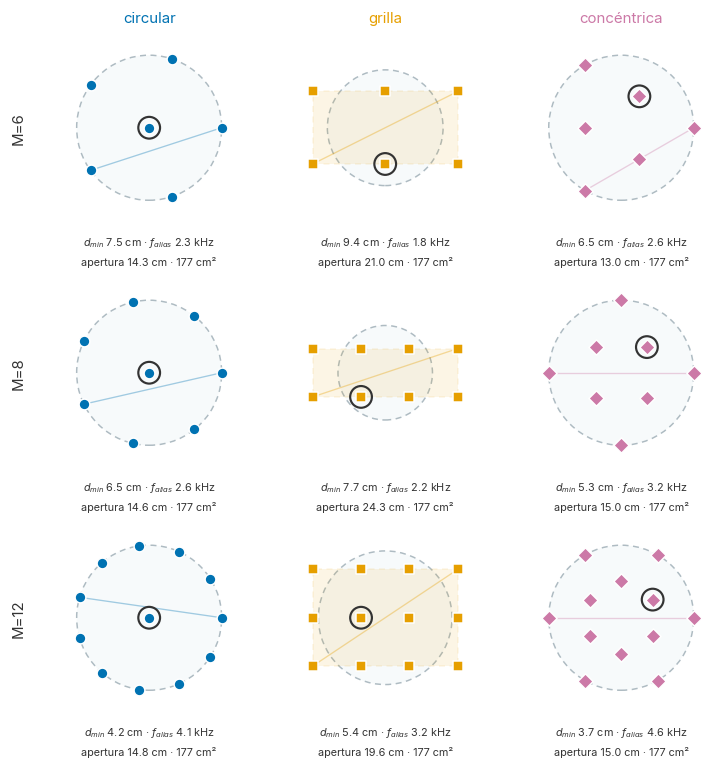

In [9]:
import sys
import matplotlib.patches as mpatches

# El único import que necesita esta figura es geometría pura: reconstruye las
# mismas coordenadas que usó el motor, no depende del dataset de Fase 3.
REPO_ROOT_BF = "/home/matias/Documents/Tesis/Vision-Aided-Beamformer"
if f"{REPO_ROOT_BF}/src" not in sys.path:
    sys.path.insert(0, f"{REPO_ROOT_BF}/src")
from beamforming.array.geometry import generate_array_coords, select_reference_mic

# --- Arreglo -------------------------------------------------------------
M_LIST_F3 = [6, 8, 12]
DIAMETER_F3 = 0.15                                 # [m] circulo de referencia
A_REF_F3 = np.pi * (DIAMETER_F3 / 2.0) ** 2         # [m^2] superficie comun a las 3
TOPOLOGIES_F3 = ["circular_center", "grid", "concentric"]  # espiral descartada
TOPOLOGY_KWARGS_F3 = {"grid": {"area_mode": "span"}}
C_SOUND = 343.0
EDGE_F3 = "#AEBBC2"   # contorno del circulo/rectangulo de referencia

# Mismos matices Okabe-Ito que ya llevan MPDR / NM-MVDR / DTLN-mono en el resto
# de la tesis: la topología es un eje de diseño distinto y no comparte figura
# con esos procesadores, así que reciclar el color no genera ambigüedad (mismo
# criterio que BAN/PF/BANPF en la Fase 2).
TOPO_COLOR_F3 = {"circular_center": OKABE_ITO["azul"], "grid": OKABE_ITO["naranja"],
                 "concentric": OKABE_ITO["purpura"]}
TOPO_LABEL_F3 = {"circular_center": "circular", "grid": "grilla", "concentric": "concéntrica"}
TOPO_MARKER_F3 = {"circular_center": "o", "grid": "s", "concentric": "D"}

geo_rows_f3 = []
for M in M_LIST_F3:
    for topo in TOPOLOGIES_F3:
        c = generate_array_coords(topo, M, DIAMETER_F3, **TOPOLOGY_KWARGS_F3.get(topo, {}))[:, :2]
        dd = np.linalg.norm(c[:, None, :] - c[None, :, :], axis=-1)
        d_min = dd[dd > 0].min()
        span = c.max(axis=0) - c.min(axis=0)
        area = span[0] * span[1] if topo == "grid" else A_REF_F3
        geo_rows_f3.append({"M": M, "topologia": topo, "d_min_cm": d_min * 100,
                            "f_alias_kHz": C_SOUND / (2 * d_min) / 1e3,
                            "apertura_cm": dd.max() * 100, "area_cm2": area * 1e4})
GEO_F3 = pd.DataFrame(geo_rows_f3)

fig, axes = plt.subplots(len(M_LIST_F3), len(TOPOLOGIES_F3),
                         figsize=(TEXTWIDTH_IN, 6.3), layout="constrained")
axes = np.atleast_2d(axes)

for r, M in enumerate(M_LIST_F3):
    for cix, topo in enumerate(TOPOLOGIES_F3):
        ax = axes[r, cix]
        colr = TOPO_COLOR_F3[topo]
        c = generate_array_coords(topo, M, DIAMETER_F3, **TOPOLOGY_KWARGS_F3.get(topo, {}))[:, :2]
        ref = select_reference_mic(c)
        g = GEO_F3[(GEO_F3.M == M) & (GEO_F3.topologia == topo)].iloc[0]

        # circulo de referencia (A_ref) + rectangulo equivalente por area (grilla)
        ax.add_patch(mpatches.Circle((0, 0), DIAMETER_F3 / 2, ec=EDGE_F3, fc="#F7FAFB",
                                     ls=(0, (4, 3)), lw=0.9, zorder=0))
        if topo == "grid":
            lo, hi = c.min(axis=0), c.max(axis=0)
            ax.add_patch(mpatches.Rectangle(lo, *(hi - lo), ec=colr, fc=colr,
                                            alpha=0.10, lw=0.9, ls=(0, (4, 3)), zorder=0))
        # apertura maxima, como segmento tenue
        dd = np.linalg.norm(c[:, None, :] - c[None, :, :], axis=-1)
        i, j = np.unravel_index(np.argmax(dd), dd.shape)
        ax.plot(*zip(c[i], c[j]), color=colr, lw=0.8, alpha=0.35, zorder=1)

        ax.scatter(c[:, 0], c[:, 1], s=42, c=colr, marker=TOPO_MARKER_F3[topo],
                   ec="white", lw=0.9, zorder=3)
        ax.scatter(*c[ref], s=170, facecolors="none", edgecolors=TRAZO, lw=1.3, zorder=4)

        lim = max(DIAMETER_F3 / 2, np.abs(c).max()) * 1.32
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xticks=[], yticks=[])
        ax.set_aspect("equal")
        ax.grid(False)
        for sp in ax.spines.values():
            sp.set_visible(False)

        if r == 0:
            ax.set_title(TOPO_LABEL_F3[topo], color=colr)
        if cix == 0:
            ax.text(-0.18, 0.5, f"M={M}", transform=ax.transAxes, rotation=90,
                    ha="center", va="center", color=TRAZO)
        ax.text(0.5, -0.06,
               f"$d_{{min}}$ {g.d_min_cm:.1f} cm · $f_{{alias}}$ {g.f_alias_kHz:.1f} kHz",
               transform=ax.transAxes, ha="center", va="top", fontsize=6.5, color=TRAZO)
        ax.text(0.5, -0.17, f"apertura {g.apertura_cm:.1f} cm · {g.area_cm2:.0f} cm²",
               transform=ax.transAxes, ha="center", va="top", fontsize=6.5, color=TRAZO)

save_fig(fig, "F3_topologias")
plt.show()

### Figura 6 — Escena de prueba: sala, arreglo, toroide de locutores e interferencias

Una combinación representativa del banco (sala *aula*, arreglo `grid`,
$M=12$): las 60 escenas *(target, interferencia)* superpuestas, que se
reutilizan **idénticas** en las 27 combinaciones sala × topología × $M$ del
barrido — un diseño pareado, no 27 sorteos distintos.

El target vive en un **toroide apoyado sobre el piso** (radio mayor 1,10 m,
tubo de 45 cm), no en un domo: modela gente hablando *alrededor* del
dispositivo, con elevaciones acotadas y realistas. La interferencia se sortea
**uniforme en el volumen** de la sala.

La cámara queda más alta que en el notebook de análisis (elevación 20° →
32°): a 20° el toroide se ve casi de canto y el arreglo, en el centro del
anillo, queda escondido; pasado los ~40° la sala se aplana demasiado y se
pierde la pared de fondo. Al arreglo y al micrófono de referencia se les
agregó además un halo blanco, porque a esta elevación varios targets
proyectan cerca del centro del anillo por perspectiva y tapaban el racimo de
micrófonos.

[ok] F3_escena3d  15.5 x 9.6 cm  ->  F3_escena3d.pdf, F3_escena3d.png


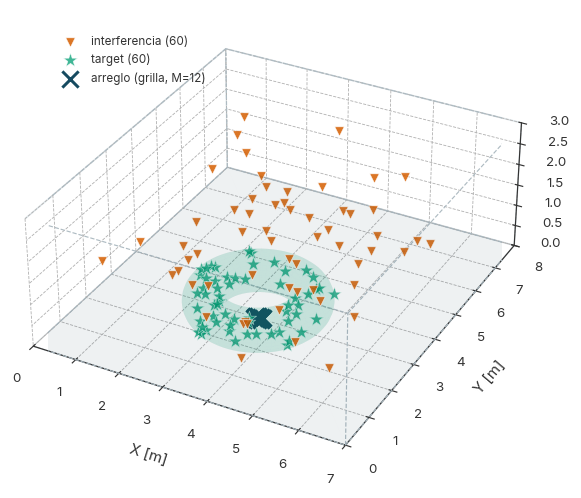

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (habilita la proyeccion 3d)
from beamforming.array.geometry import place_spherical

DATA_DIR_F3 = Path("../data/Fase_3/array_circcenter_nmmvdr").resolve()
df_F3 = pd.read_parquet(DATA_DIR_F3 / "ism_benchmark_metrics.parquet")

ROOM_PROFILES_F3 = {0.30: np.array([6.0, 7.0, 2.8]),
                    0.50: np.array([7.0, 8.0, 3.0]),
                    0.80: np.array([9.0, 11.0, 3.5])}
BAFFLE_HEIGHT_F3 = 0.005
ARRAY_CENTER_MAP_F3 = {0.30: np.array([3.0, 2.5, BAFFLE_HEIGHT_F3]),
                       0.50: np.array([3.5, 3.0, BAFFLE_HEIGHT_F3]),
                       0.80: np.array([4.5, 3.5, BAFFLE_HEIGHT_F3])}
TORUS_R_MAYOR_F3, TORUS_R_TUBO_F3 = 1.10, 0.45   # toroide de locutores, tangente al piso
GRIDC_F3 = "#DFE6EA"

# Escenas unicas (60 pares target/interferencia, compartidas por las 3 salas x
# 3 topologias x 3 M -> promediar por escena es inocuo, ptp intra-escena < 0.5 deg).
SCN_F3 = (df_F3.groupby("interf_scenario")[
             ["source_azimuth_deg", "source_elevation_deg", "source_slant_m",
              "interf_azimuth_deg", "interf_elevation_deg", "interf_slant_m"]]
            .mean())
SCENE_IDS_F3 = sorted(SCN_F3.index)
N_SCENES_F3 = len(SCENE_IDS_F3)

# Combinacion representativa; la escena es estructuralmente igual en las 27
# combinaciones sala x topologia x M (ver Figura 5 para M_LIST_F3/DIAMETER_F3).
RT_SHOW, TOPO_SHOW, M_SHOW = 0.50, "grid", M_LIST_F3[-1]
ac_f3 = np.asarray(ARRAY_CENTER_MAP_F3[RT_SHOW], float).copy()
room_f3 = np.asarray(ROOM_PROFILES_F3[RT_SHOW], float).copy()
mic_f3 = generate_array_coords(TOPO_SHOW, M_SHOW, DIAMETER_F3,
                               **TOPOLOGY_KWARGS_F3.get(TOPO_SHOW, {})) + ac_f3
ref_f3 = select_reference_mic(mic_f3)

tgt_f3 = np.array([place_spherical(*SCN_F3.loc[s, ["source_azimuth_deg", "source_elevation_deg",
                                                    "source_slant_m"]], ac_f3) for s in SCENE_IDS_F3])
itf_f3 = np.array([place_spherical(*SCN_F3.loc[s, ["interf_azimuth_deg", "interf_elevation_deg",
                                                    "interf_slant_m"]], ac_f3) for s in SCENE_IDS_F3])

C_TGT_F3, C_ITF_F3, C_ARR_F3 = OKABE_ITO["verde"], OKABE_ITO["bermellon"], "#164A60"


def _room_box_f3(ax, room, **kw):
    x, y, z = room
    P = np.array([[0, 0, 0], [x, 0, 0], [x, y, 0], [0, y, 0],
                  [0, 0, z], [x, 0, z], [x, y, z], [0, y, z]], float)
    for a, b in [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]:
        ax.plot(*zip(P[a], P[b]), **kw)


def _torus_f3(ax, center, R, r, **kw):
    u = np.linspace(0, 2 * np.pi, 72); v = np.linspace(0, 2 * np.pi, 28)
    U, V = np.meshgrid(u, v)
    ax.plot_surface(center[0] + (R + r * np.cos(V)) * np.sin(U),
                    center[1] + (R + r * np.cos(V)) * np.cos(U),
                    r + r * np.sin(V), **kw)


fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 0.62))
ax = fig.add_subplot(111, projection="3d")
_room_box_f3(ax, room_f3, color=EDGE_F3, ls="--", lw=0.7)
ax.plot_trisurf([0, room_f3[0], room_f3[0], 0], [0, 0, room_f3[1], room_f3[1]], [0] * 4,
               color=C_ARR_F3, alpha=0.07, linewidth=0)
_torus_f3(ax, ac_f3, TORUS_R_MAYOR_F3, TORUS_R_TUBO_F3, color=C_TGT_F3, alpha=0.09,
         linewidth=0, antialiased=True, shade=False)

ax.scatter(*itf_f3.T, c=C_ITF_F3, marker="v", s=32, depthshade=False, alpha=0.85,
          ec="white", lw=0.4, label=f"interferencia ({N_SCENES_F3})", zorder=1)
ax.scatter(*tgt_f3.T, c=C_TGT_F3, marker="*", s=80, depthshade=False, alpha=0.75,
          ec="white", lw=0.4, label=f"target ({N_SCENES_F3})", zorder=2)
# Halo blanco atras del arreglo: sin el, el racimo de micros se pierde detras
# de los targets que, por la perspectiva, proyectan cerca del centro del anillo.
ax.scatter(*mic_f3.T, c="white", marker="x", s=95, depthshade=False, linewidths=3.2, zorder=3)
ax.scatter(*mic_f3.T, c=C_ARR_F3, marker="x", s=95, depthshade=False, linewidths=1.8,
          label=f"arreglo ({TOPO_LABEL_F3[TOPO_SHOW]}, M={M_SHOW})", zorder=4)
ax.scatter(*mic_f3[ref_f3], facecolors="none", edgecolors="white", s=190, lw=3.0,
          depthshade=False, zorder=5)

ax.set(xlabel="X [m]", ylabel="Y [m]", zlabel="Z [m]",
      xlim=(0, room_f3[0]), ylim=(0, room_f3[1]), zlim=(0, room_f3[2]))
for pane in (ax.xaxis, ax.yaxis, ax.zaxis):
    pane.pane.set_facecolor("white"); pane.pane.set_edgecolor(GRIDC_F3); pane.pane.set_alpha(1.0)
ax.grid(True, color=GRIDC_F3, lw=0.5)
# Elevacion levantada respecto de la libreta de analisis (20 -> 32 grados): ver
# la justificacion en la celda markdown de arriba.
ax.view_init(elev=32, azim=-62)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.97), fontsize=7, frameon=False)
ax.set_box_aspect(tuple(room_f3), zoom=1.16)
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

save_fig(fig, "F3_escena3d")
plt.show()

## Resultados del barrido de topología

De acá en adelante todas las figuras usan **NM-MVDR** (el sistema real, ya
elegido en las Fases 1 y 2) sobre las 540 escenas por topología (60 escenas ×
3 salas × 3 valores de $M$). El techo oracle (`Souden` con SCM ideal) se deja
fuera por decisión de curaduría: en el notebook de análisis sirve para
confirmar que el ranking de topologías no es un artefacto de la máscara del
DTLN, pero el orden no cambia con él, así que no aporta a esta sección — sigue
estando en los datos y en `Fase_3_array_analysis.ipynb`.

In [11]:
METRICS_F3 = ["PESQ", "STOI", "SIR", "SI-SDR"]
MSHORT_F3 = {"PESQ": "Δ PESQ", "STOI": "Δ STOI", "SIR": "Δ SIR [dB]", "SI-SDR": "Δ SI-SDR [dB]"}

KEEP_F3 = ["topology", "M", "rt60", "source_elevation_deg", "interf_elevation_deg"]
view_F3 = (df_F3[df_F3.processor == "NM_MVDR"]
          [KEEP_F3 + [f"Delta_tot_{m}_early" for m in METRICS_F3]]
          .rename(columns={f"Delta_tot_{m}_early": m for m in METRICS_F3})
          .copy())
view_F3["topology"] = pd.Categorical(view_F3["topology"], categories=TOPOLOGIES_F3, ordered=True)

# Bins de elevacion del target: el toroide la barre de forma controlada (~5-43 deg).
EL_EDGES_SRC_F3 = np.arange(0, 50, 7.5)
view_F3["el_src_mid"] = (pd.cut(view_F3["source_elevation_deg"], EL_EDGES_SRC_F3)
                         .map(lambda b: b.mid if pd.notna(b) else np.nan).astype(float))

# Bins de elevacion de la interferencia: sorteada uniforme en el volumen de la
# sala, llega mucho mas arriba que el target (~0-68 deg) -> bins mas anchos.
EL_EDGES_ITF_F3 = np.arange(0, 75, 10)
view_F3["el_itf_mid"] = (pd.cut(view_F3["interf_elevation_deg"], EL_EDGES_ITF_F3)
                         .map(lambda b: b.mid if pd.notna(b) else np.nan).astype(float))

print(f"Fase 3 (NM-MVDR): {len(view_F3)} filas | "
      f"{view_F3.groupby('topology', observed=True).size().to_dict()} escenas por topologia")

Fase 3 (NM-MVDR): 1620 filas | {'circular_center': 540, 'grid': 540, 'concentric': 540} escenas por topologia


### Figura 7 — Efecto del número de micrófonos ($M$)

Mediana de cada métrica por $M$, una curva por topología. Con el área fija en
$A_{ref}$ (Figura 5), subir $M$ no agranda el arreglo — son más micrófonos
*más juntos*, no un arreglo más grande. Se gana promediado (más canales para
estimar la matriz de covarianza y más ganancia de array) pero no apertura, y
por eso las tres curvas suben casi en paralelo: ninguna topología aprovecha
mejor los micrófonos extra que las otras.

[ok] F3_tendencias_M  15.5 x 6.6 cm  ->  F3_tendencias_M.pdf, F3_tendencias_M.png


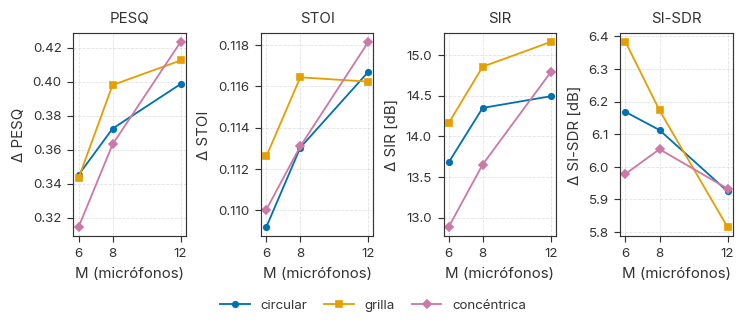

In [12]:
fig, axes = plt.subplots(1, len(METRICS_F3), figsize=(TEXTWIDTH_IN, 2.6), layout="constrained")
for ax, metric in zip(axes, METRICS_F3):
    piv = (view_F3.pivot_table(index="M", columns="topology", values=metric,
                               aggfunc="median", observed=True).reindex(M_LIST_F3))
    for topo in TOPOLOGIES_F3:
        ax.plot(piv.index, piv[topo].values, marker=TOPO_MARKER_F3[topo],
                color=TOPO_COLOR_F3[topo], label=TOPO_LABEL_F3[topo])
    ax.set(xticks=M_LIST_F3, xlabel="M (micrófonos)", ylabel=MSHORT_F3[metric], title=metric)
    ax.grid(True)
    ax.set_axisbelow(True)

handles = [Line2D([0], [0], color=TOPO_COLOR_F3[t], marker=TOPO_MARKER_F3[t], label=TOPO_LABEL_F3[t])
          for t in TOPOLOGIES_F3]
fig.legend(handles=handles, loc="outside lower center", ncol=len(TOPOLOGIES_F3),
           frameon=False, handlelength=2.2, columnspacing=1.3)

save_fig(fig, "F3_tendencias_M")
plt.show()

### Figura 8 — Efecto de la elevación del target

Mediana de cada métrica por bin de 7,5° de elevación del target, sobre el
rango real que cubre el toroide (≈ 5–43°, Figura 6). Las tres topologías son
planares, así que la elevación es en principio su eje débil: la proyección
del desplazamiento angular sobre el plano del arreglo se achica con
$\cos(\text{elevación})$. Dentro del rango que efectivamente cubre la escena,
sin embargo, no hay una caída: las curvas son ruidosas pero sin tendencia, y
el orden entre topologías (grilla arriba) se mantiene en todo el rango.

[ok] F3_tendencias_elev_target  15.5 x 6.6 cm  ->  F3_tendencias_elev_target.pdf, F3_tendencias_elev_target.png


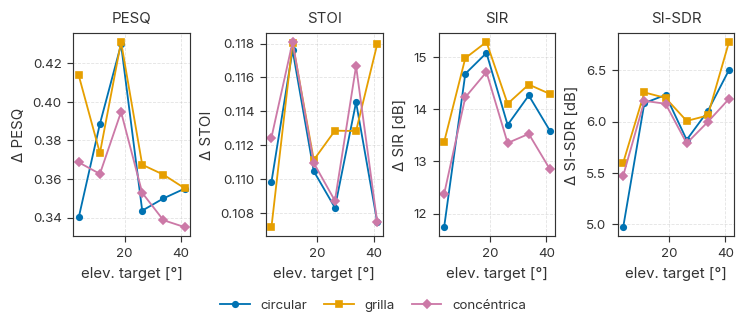

In [13]:
fig, axes = plt.subplots(1, len(METRICS_F3), figsize=(TEXTWIDTH_IN, 2.6), layout="constrained")
for ax, metric in zip(axes, METRICS_F3):
    piv = view_F3.pivot_table(index="el_src_mid", columns="topology", values=metric,
                              aggfunc="median", observed=True)
    for topo in TOPOLOGIES_F3:
        ax.plot(piv.index, piv[topo].values, marker=TOPO_MARKER_F3[topo],
                color=TOPO_COLOR_F3[topo], label=TOPO_LABEL_F3[topo])
    ax.set(xlabel="elev. target [°]", ylabel=MSHORT_F3[metric], title=metric)
    ax.grid(True)
    ax.set_axisbelow(True)

fig.legend(handles=handles, loc="outside lower center", ncol=len(TOPOLOGIES_F3),
           frameon=False, handlelength=2.2, columnspacing=1.3)

save_fig(fig, "F3_tendencias_elev_target")
plt.show()

### Figura 9 — Efecto de la elevación de la interferencia

Mismo análisis que la Figura 8, ahora sobre la elevación de la
**interferencia** en vez del target — una vista que no está en el notebook de
análisis. A diferencia del target, que el toroide mantiene siempre bajo, la
interferencia se sortea uniforme en todo el volumen de la sala y llega hasta
≈ 68° de elevación (bins de 10°). El resultado es el mismo que con el target:
las curvas no muestran una tendencia clara con la elevación de la
interferencia, y el orden entre topologías se mantiene sin importar de dónde
venga — el eje que manda en este barrido es la apertura del arreglo, no la
posición angular de ninguna de las dos fuentes.

[ok] F3_tendencias_elev_interf  15.5 x 6.6 cm  ->  F3_tendencias_elev_interf.pdf, F3_tendencias_elev_interf.png


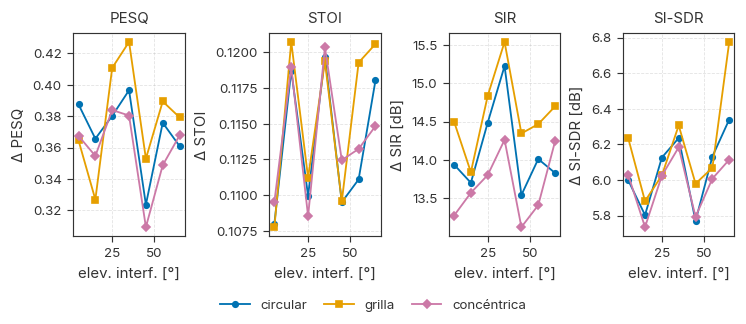

In [14]:
fig, axes = plt.subplots(1, len(METRICS_F3), figsize=(TEXTWIDTH_IN, 2.6), layout="constrained")
for ax, metric in zip(axes, METRICS_F3):
    piv = view_F3.pivot_table(index="el_itf_mid", columns="topology", values=metric,
                              aggfunc="median", observed=True)
    for topo in TOPOLOGIES_F3:
        ax.plot(piv.index, piv[topo].values, marker=TOPO_MARKER_F3[topo],
                color=TOPO_COLOR_F3[topo], label=TOPO_LABEL_F3[topo])
    ax.set(xlabel="elev. interf. [°]", ylabel=MSHORT_F3[metric], title=metric)
    ax.grid(True)
    ax.set_axisbelow(True)

fig.legend(handles=handles, loc="outside lower center", ncol=len(TOPOLOGIES_F3),
           frameon=False, handlelength=2.2, columnspacing=1.3)

save_fig(fig, "F3_tendencias_elev_interf")
plt.show()

### Figura 10 — Resultados globales (dispersión escena a escena)

Distribución completa de las 540 escenas por topología: caja = cuartiles,
línea = mediana, bigotes = percentiles 5–95 (sin atípicos individuales, dado
el volumen de puntos). La mediana rankea, pero no dice nada sobre
consistencia: el ancho de cada caja frente a la distancia entre las tres
medianas es la lectura central de esta figura — la escena pesa mucho más que
la topología.

[ok] F3_boxplot_global  15.5 x 5.3 cm  ->  F3_boxplot_global.pdf, F3_boxplot_global.png


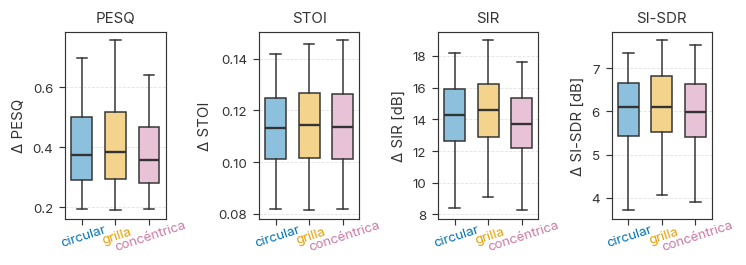

In [15]:
fig, axes = plt.subplots(1, len(METRICS_F3), figsize=(TEXTWIDTH_IN, 2.1), layout="constrained")
for ax, metric in zip(axes, METRICS_F3):
    datos, colores = [], []
    for topo in TOPOLOGIES_F3:
        datos.append(view_F3.loc[view_F3.topology == topo, metric].dropna().values)
        colores.append(TOPO_COLOR_F3[topo])

    bp = ax.boxplot(
        datos, positions=np.arange(len(datos)), widths=0.62, patch_artist=True,
        whis=(5, 95), showfliers=False,
        boxprops=dict(lw=0.9, edgecolor=TRAZO),
        medianprops=dict(color=TRAZO, lw=1.4),
        whiskerprops=dict(color=TRAZO, lw=0.9),
        capprops=dict(color=TRAZO, lw=0.9),
    )
    for caja, c in zip(bp["boxes"], colores):
        caja.set_facecolor(tint(c))

    ax.set_ylabel(MSHORT_F3[metric])
    ax.set_title(metric)
    ax.set_xticks(np.arange(len(TOPOLOGIES_F3)))
    ax.set_xticklabels([TOPO_LABEL_F3[t] for t in TOPOLOGIES_F3], rotation=18, ha="center",
                       rotation_mode="anchor")
    for lbl, topo in zip(ax.get_xticklabels(), TOPOLOGIES_F3):
        lbl.set_color(TOPO_COLOR_F3[topo])
    ax.grid(axis="y")
    ax.set_axisbelow(True)

save_fig(fig, "F3_boxplot_global")
plt.show()